In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
# Raw data lives 3 levels above the notebooks/ folder (IT20 root)
file_name = "WA_Fn-UseC_-Accounts-Receivable.csv"
data_path = os.path.join("..", "..", "..", file_name)

df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()
df.head()

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate
0,391,0379-NEVHP,4/6/2013,611365,1/2/2013,2/1/2013,55.94,No,1/15/2013,Paper,13,0
1,406,8976-AMJEO,3/3/2012,7900770,1/26/2013,2/25/2013,61.74,Yes,3/3/2013,Electronic,36,6
2,391,2820-XGXSB,1/26/2012,9231909,7/3/2013,8/2/2013,65.88,No,7/8/2013,Electronic,5,0
3,406,9322-YCTQO,4/6/2012,9888306,2/10/2013,3/12/2013,105.92,No,3/17/2013,Electronic,35,5
4,818,6627-ELFBK,11/26/2012,15752855,10/25/2012,11/24/2012,72.27,Yes,11/28/2012,Paper,34,4


In [3]:
print('---------------- INFO ---------------------\n')
print(df.info(), '\n')

print('------------ DESCRIBE -------------\n')
print(df.describe(), '\n')

print('------------- NULL VALUES -----------\n')
print(df.isna().sum(), '\n')

print('------------- DUPLICATED SAMPLE -----------\n')
print(df.duplicated().sum(), '\n')

print('------------ HEAD -----------------')
print(df.head(), '\n')

---------------- INFO ---------------------

<class 'pandas.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryCode    2466 non-null   int64  
 1   customerID     2466 non-null   str    
 2   PaperlessDate  2466 non-null   str    
 3   invoiceNumber  2466 non-null   int64  
 4   InvoiceDate    2466 non-null   str    
 5   DueDate        2466 non-null   str    
 6   InvoiceAmount  2466 non-null   float64
 7   Disputed       2466 non-null   str    
 8   SettledDate    2466 non-null   str    
 9   PaperlessBill  2466 non-null   str    
 10  DaysToSettle   2466 non-null   int64  
 11  DaysLate       2466 non-null   int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 364.7 KB
None 

------------ DESCRIBE -------------

       countryCode  invoiceNumber  InvoiceAmount  DaysToSettle     DaysLate
count  2466.000000   2.466000e+03    2466.000000    2466.00000 

Target distribution:
 Disputed
No     1905
Yes     561
Name: count, dtype: int64
Dispute rate: 22.7%


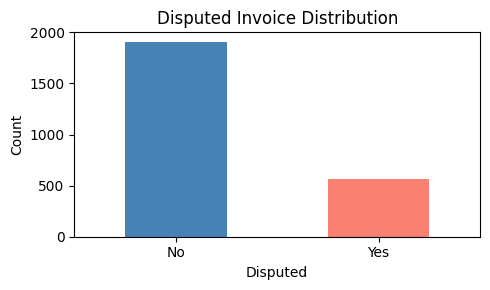

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target class distribution
counts = df['Disputed'].value_counts()
print('Target distribution:\n', counts)
print(f"Dispute rate: {counts['Yes'] / len(df) * 100:.1f}%")

plt.figure(figsize=(5, 3))
counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Disputed Invoice Distribution')
plt.xlabel('Disputed')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Parse dates and engineer leakage-free features (available at invoice issuance)
df['InvoiceDate']    = pd.to_datetime(df['InvoiceDate'])
df['DueDate']        = pd.to_datetime(df['DueDate'])
df['PaperlessDate']  = pd.to_datetime(df['PaperlessDate'])

df['CreditTermDays']     = (df['DueDate'] - df['InvoiceDate']).dt.days
df['InvoiceMonth']       = df['InvoiceDate'].dt.month
df['InvoiceDayOfWeek']   = df['InvoiceDate'].dt.dayofweek
df['InvoiceQuarter']     = df['InvoiceDate'].dt.quarter
df['DaysSincePaperless'] = (df['InvoiceDate'] - df['PaperlessDate']).dt.days.clip(lower=0)

# CustomerFreq: number of past invoices per customer (using invoice order)
df = df.sort_values('InvoiceDate').reset_index(drop=True)
df['CustomerFreq'] = df.groupby('customerID').cumcount()

# Encode target
df['target'] = (df['Disputed'].str.strip().str.lower() == 'yes').astype(int)

df.head()

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,CreditTermDays,InvoiceMonth,InvoiceDayOfWeek,InvoiceQuarter,DaysSincePaperless,CustomerFreq,target
0,391,6708-DPYTF,2012-08-02,5133177585,2012-01-03,2012-02-02,55.37,No,2/16/2012,Paper,44,14,30,1,1,1,0,0,0
1,770,3993-QUNVJ,2012-12-31,280670965,2012-01-03,2012-02-02,50.39,No,1/23/2012,Paper,20,0,30,1,1,1,0,0,0
2,406,5164-VMYWJ,2013-11-27,6393629835,2012-01-03,2012-02-02,71.33,No,1/30/2012,Paper,27,0,30,1,1,1,0,0,0
3,818,1604-LIFKX,2013-03-16,5928070131,2012-01-03,2012-02-02,97.60,No,2/25/2012,Paper,53,23,30,1,1,1,0,0,0
4,818,8887-NCUZC,2013-01-22,6050714721,2012-01-03,2012-02-02,15.99,Yes,2/15/2012,Paper,43,13,30,1,1,1,0,0,1


In [6]:
print('------------- countryCode Column Values ---------------')
print(df['countryCode'].unique(), '\n')
print('------------- PaperlessBill Column Values ---------------')
print(df['PaperlessBill'].unique(), '\n')

------------- countryCode Column Values ---------------
[391 770 406 818 897] 

------------- PaperlessBill Column Values ---------------
<ArrowStringArray>
['Paper', 'Electronic']
Length: 2, dtype: str 



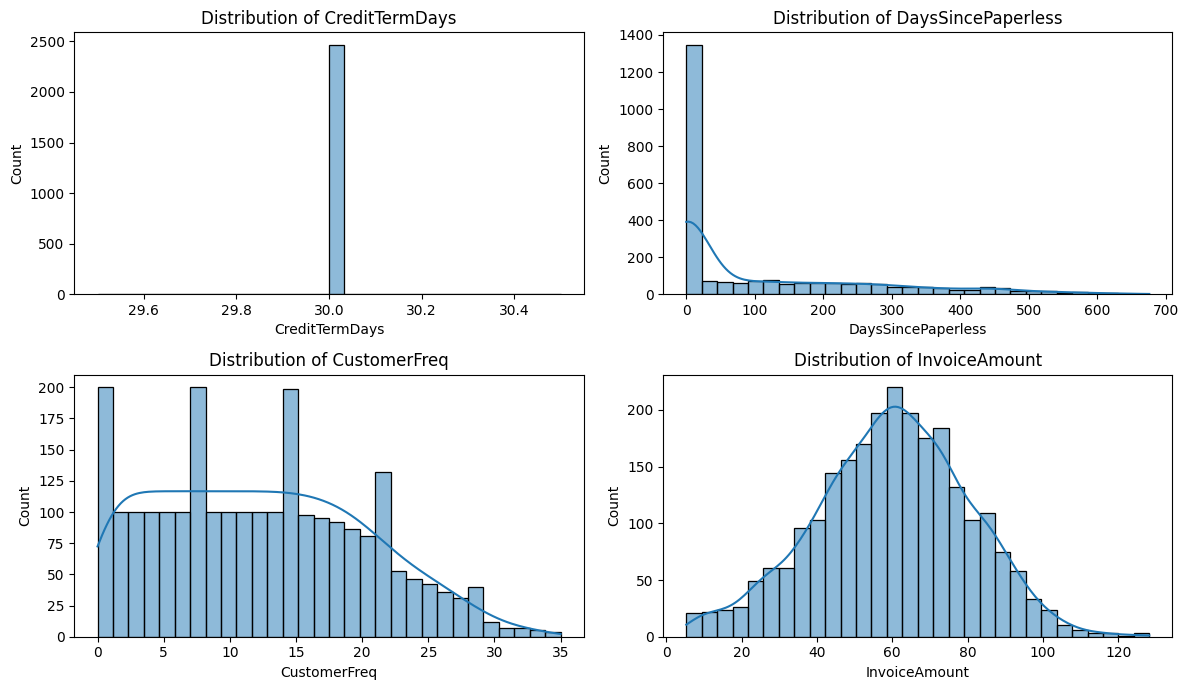

In [7]:
# Distribution of engineered numeric features
eng_cols = ['CreditTermDays', 'DaysSincePaperless', 'CustomerFreq', 'InvoiceAmount']
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.flat, eng_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=30)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

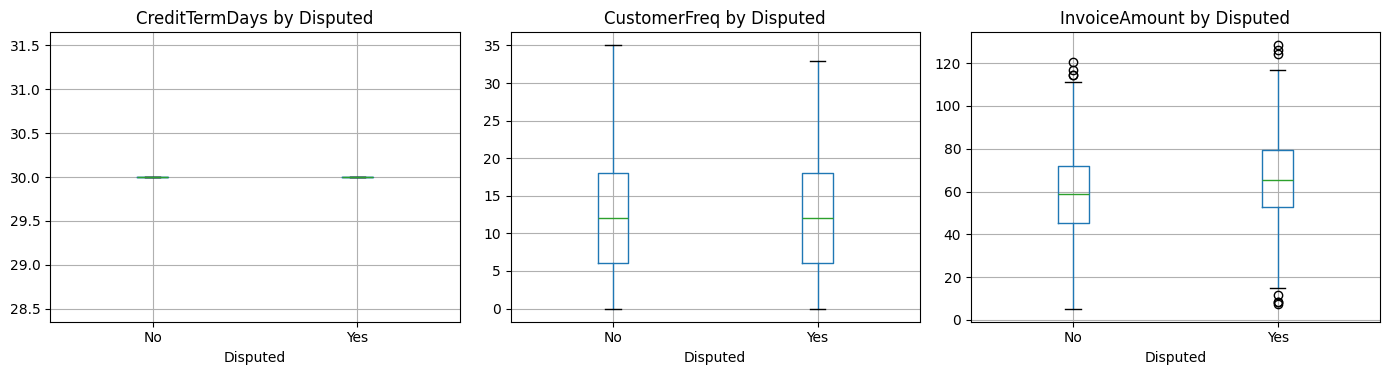

In [8]:
# Engineered features vs dispute outcome
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['CreditTermDays', 'CustomerFreq', 'InvoiceAmount']):
    df.boxplot(column=col, by='Disputed', ax=ax)
    ax.set_title(f'{col} by Disputed')
    ax.set_xlabel('Disputed')
plt.suptitle('')
plt.tight_layout()
plt.show()

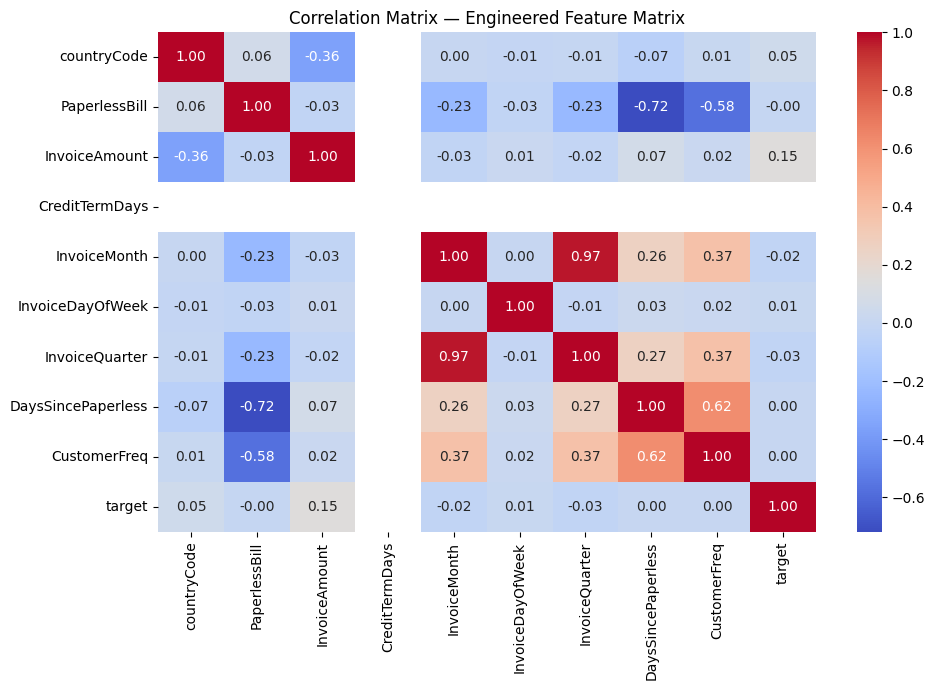

In [9]:
# Correlation heatmap (encoded copy)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_enc = df[['countryCode', 'PaperlessBill', 'InvoiceAmount',
             'CreditTermDays', 'InvoiceMonth', 'InvoiceDayOfWeek',
             'InvoiceQuarter', 'DaysSincePaperless', 'CustomerFreq', 'target']].copy()
df_enc['countryCode']  = le.fit_transform(df_enc['countryCode'].astype(str))
df_enc['PaperlessBill'] = le.fit_transform(df_enc['PaperlessBill'].astype(str))

plt.figure(figsize=(10, 7))
sns.heatmap(df_enc.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix — Engineered Feature Matrix')
plt.tight_layout()
plt.show()

In [11]:
# Drop future-leaking columns before saving
LEAKY = ['DaysToSettle', 'DaysLate', 'SettledDate', 'InvoiceDate', 'DueDate', 'PaperlessDate']
df_clean = df.drop(columns=[c for c in LEAKY if c in df.columns])

TO_DROP = ['Disputed', 'InvoiceNumber']
df_clean = df_clean.drop(columns=[c for c in TO_DROP if c in df_clean.columns])  # keep target column

os.makedirs('../datasets/processed', exist_ok=True)
df_clean.to_csv('../datasets/processed/processed_ar.csv', index=False)
print('Saved processed dataset. Shape:', df_clean.shape)
df_clean.head()

Saved processed dataset. Shape: (2466, 12)


,countryCode,customerID,invoiceNumber,InvoiceAmount,PaperlessBill,CreditTermDays,InvoiceMonth,InvoiceDayOfWeek,InvoiceQuarter,DaysSincePaperless,CustomerFreq,target
0,391,6708-DPYTF,5133177585,55.37,Paper,30,1,1,1,0,0,0
1,770,3993-QUNVJ,280670965,50.39,Paper,30,1,1,1,0,0,0
2,406,5164-VMYWJ,6393629835,71.33,Paper,30,1,1,1,0,0,0
3,818,1604-LIFKX,5928070131,97.60,Paper,30,1,1,1,0,0,0
4,818,8887-NCUZC,6050714721,15.99,Paper,30,1,1,1,0,0,1
